In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv("HogayaFinally.csv")

In [4]:
X = df.drop("Severity", axis=1)

In [5]:
y = df["Severity"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [7]:
print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {2: 317496, 3: 67588, 4: 10320, 1: 3409}
After SMOTE: {2: 317496, 3: 317496, 4: 317496, 1: 317496}


In [8]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [9]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,                # increased from 20
    scoring='recall_macro',   # optimize recall
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [10]:
random_search.fit(X_train_res, y_train_res)

print("\nBest Parameters:", random_search.best_params_)
print("Best Cross-Validation Recall:", random_search.best_score_)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best Cross-Validation Recall: 0.9185477927280973



Accuracy: <function accuracy_score at 0x00000253BEFF8720>
Macro Recall: <function recall_score at 0x00000253BEFF9800>

Confusion Matrix:
 [[  460   322    63     7]
 [  177 71180  7306   712]
 [  111  6353 10156   277]
 [    8  1695   258   619]]

Classification Report:
               precision    recall  f1-score   support

           1       0.61      0.54      0.57       852
           2       0.89      0.90      0.90     79375
           3       0.57      0.60      0.59     16897
           4       0.38      0.24      0.30      2580

    accuracy                           0.83     99704
   macro avg       0.61      0.57      0.59     99704
weighted avg       0.82      0.83      0.82     99704


Top 15 Important Features:

                   Feature  Importance
13                    Year    0.138794
25          Source_Source2    0.118152
0             Distance(mi)    0.116332
12        Duration_Minutes    0.099803
14                   Month    0.052161
1           Temperature(F)   

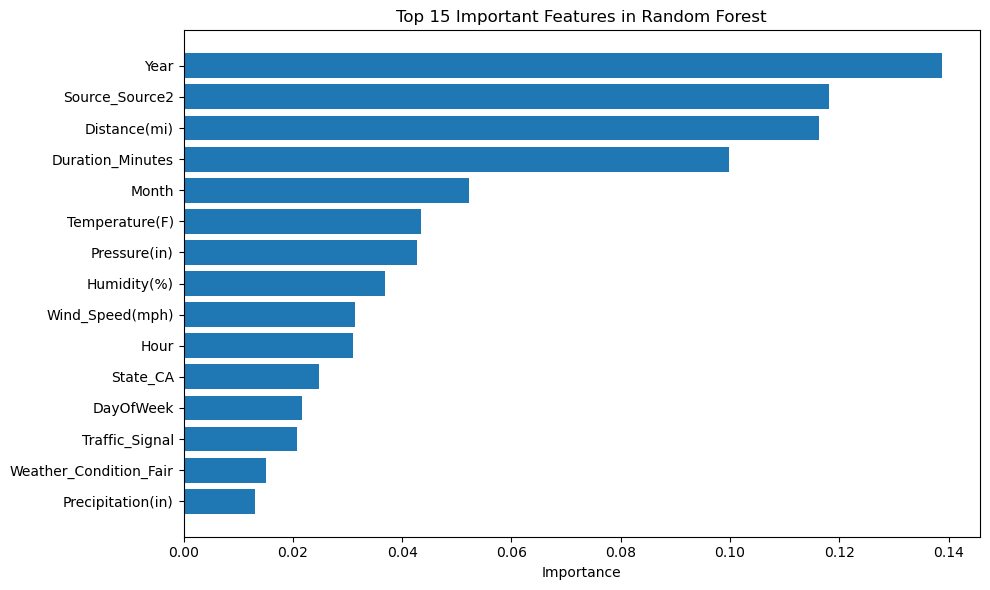

In [13]:
print("\nAccuracy:", accuracy_score)
print("Macro Recall:", recall_score)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 15 Important Features:\n")
print(feature_importances.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importances['Feature'].head(15)[::-1],
    feature_importances['Importance'].head(15)[::-1]
)
plt.xlabel('Importance')
plt.title('Top 15 Important Features in Random Forest')
plt.tight_layout()
plt.show()

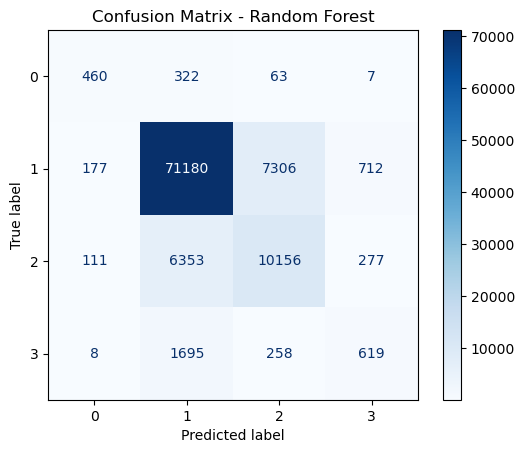

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()


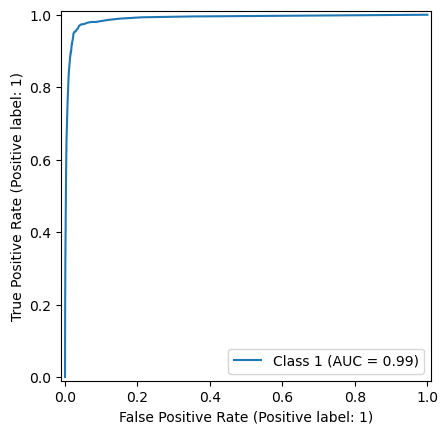

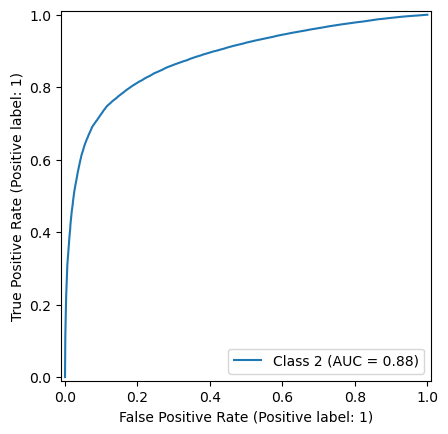

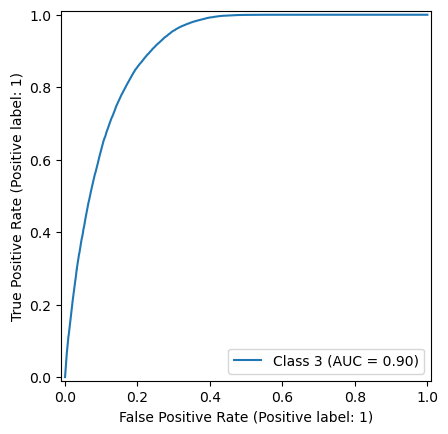

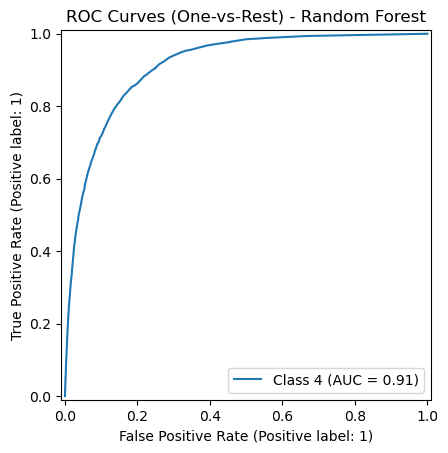

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4])
y_score = best_model.predict_proba(X_test)
for i in range(y_test_bin.shape[1]):
    RocCurveDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f'Class {i+1}'
    )

plt.title('ROC Curves (One-vs-Rest) - Random Forest')
plt.show()